# Customer Segmentation Analysis

## Objective

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

### Tech Stack
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

### Methodology
1. Data Loading and Inspection
2. Data Cleaning
3. Feature Engineering
4. RFM Analysis
5. Data Standardization
6. K-Means Clustering
7. Elbow Method
8. Cluster Visualization
9. Cluster Profiling
10. Customer Segment Analysis
11. Marketing Recommendations
12. Conclusion

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [20]:
file_path = "sales_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7991
Columns: 16


## 1. Data Loading and Initial Inspection

The dataset contains transaction-level retail/e-commerce sales information. Each row represents an order transaction with information about the customer, product, quantity, pricing, discount, sales channel, and order dates.

In [21]:
df.head()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Price,Unit Cost
0,SO - 000101,In-Store,WARE-UHY1004,12/31/2017,5/31/2018,6/14/2018,6/19/2018,USD,6,15,259,12,5,0.075,1963.1,1001.181
1,SO - 000102,Online,WARE-NMK1003,12/31/2017,5/31/2018,6/22/2018,7/2/2018,USD,14,20,196,27,3,0.075,3939.6,3348.660
2,SO - 000103,Distributor,WARE-UHY1004,12/31/2017,5/31/2018,6/21/2018,7/1/2018,USD,21,16,213,16,1,0.050,1775.5,781.220
3,SO - 000104,Wholesale,WARE-NMK1003,12/31/2017,5/31/2018,6/2/2018,6/7/2018,USD,28,48,107,23,8,0.075,2324.9,1464.687
4,SO - 000105,Distributor,WARE-NMK1003,4/10/2018,5/31/2018,6/16/2018,6/26/2018,USD,22,49,111,26,8,0.100,1822.4,1476.144


In [22]:
df.tail()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Price,Unit Cost
7986,SO - 0008087,In-Store,WARE-MKL1006,9/26/2020,12/30/2020,1/7/2021,1/14/2021,USD,9,41,339,29,1,0.075,234.5,121.940
7987,SO - 0008088,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/2/2021,1/4/2021,USD,14,29,202,3,6,0.050,3202.6,1921.560
7988,SO - 0008089,Online,WARE-UHY1004,9/26/2020,12/30/2020,1/23/2021,1/26/2021,USD,14,32,241,35,5,0.200,3825.7,2792.761
7989,SO - 0008090,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/20/2021,1/25/2021,USD,20,42,112,36,8,0.100,1072.0,804.000
7990,SO - 0008091,In-Store,WARE-UHY1004,9/26/2020,12/30/2020,1/13/2021,1/19/2021,USD,6,41,237,43,5,0.075,2211.0,1370.820


In [23]:
df.shape

(7991, 16)

In [24]:
df.columns

Index(['OrderNumber', 'Sales Channel', 'WarehouseCode', 'ProcuredDate',
       'OrderDate', 'ShipDate', 'DeliveryDate', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID', '_ProductID', 'Order Quantity',
       'Discount Applied', 'Unit Price', 'Unit Cost'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderNumber       7991 non-null   object 
 1   Sales Channel     7991 non-null   object 
 2   WarehouseCode     7991 non-null   object 
 3   ProcuredDate      7991 non-null   object 
 4   OrderDate         7991 non-null   object 
 5   ShipDate          7991 non-null   object 
 6   DeliveryDate      7991 non-null   object 
 7   CurrencyCode      7991 non-null   object 
 8   _SalesTeamID      7991 non-null   int64  
 9   _CustomerID       7991 non-null   int64  
 10  _StoreID          7991 non-null   int64  
 11  _ProductID        7991 non-null   int64  
 12  Order Quantity    7991 non-null   int64  
 13  Discount Applied  7991 non-null   float64
 14  Unit Price        7991 non-null   float64
 15  Unit Cost         7991 non-null   float64
dtypes: float64(3), int64(5), object(8)
memory 

In [26]:
df.dtypes

OrderNumber          object
Sales Channel        object
WarehouseCode        object
ProcuredDate         object
OrderDate            object
ShipDate             object
DeliveryDate         object
CurrencyCode         object
_SalesTeamID          int64
_CustomerID           int64
_StoreID              int64
_ProductID            int64
Order Quantity        int64
Discount Applied    float64
Unit Price          float64
Unit Cost           float64
dtype: object

## 2. Data Quality Check

Before performing customer segmentation, the dataset is checked for missing values, duplicate transactions, incorrect data types, and invalid numerical values.

In [28]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
OrderNumber         0
Sales Channel       0
WarehouseCode       0
ProcuredDate        0
OrderDate           0
ShipDate            0
DeliveryDate        0
CurrencyCode        0
_SalesTeamID        0
_CustomerID         0
_StoreID            0
_ProductID          0
Order Quantity      0
Discount Applied    0
Unit Price          0
Unit Cost           0
dtype: int64


In [29]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
OrderNumber,0,0.0
Sales Channel,0,0.0
WarehouseCode,0,0.0
ProcuredDate,0,0.0
OrderDate,0,0.0
ShipDate,0,0.0
DeliveryDate,0,0.0
CurrencyCode,0,0.0
_SalesTeamID,0,0.0
_CustomerID,0,0.0


In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
print("Duplicate Order Numbers:", df["OrderNumber"].duplicated().sum())

Duplicate Order Numbers: 0


In [32]:
date_columns = [
    "ProcuredDate",
    "OrderDate",
    "ShipDate",
    "DeliveryDate"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_columns].dtypes)

ProcuredDate    datetime64[ns]
OrderDate       datetime64[ns]
ShipDate        datetime64[ns]
DeliveryDate    datetime64[ns]
dtype: object


In [33]:
df[date_columns].isnull().sum()

ProcuredDate    0
OrderDate       0
ShipDate        0
DeliveryDate    0
dtype: int64

In [34]:
numeric_columns = [
    "Order Quantity",
    "Discount Applied",
    "Unit Price",
    "Unit Cost"
]

df[numeric_columns].describe()

,Order Quantity,Discount Applied,Unit Price,Unit Cost
count,7991.000000,7991.000000,7991.000000,7991.000000
mean,4.525341,0.114394,2284.536504,1431.911054
std,2.312631,0.085570,1673.096364,1112.413043
min,1.000000,0.050000,167.500000,68.675000
25%,3.000000,0.050000,1031.800000,606.115500
50%,5.000000,0.075000,1849.200000,1080.576000
75%,7.000000,0.150000,3611.300000,2040.250500
max,8.000000,0.400000,6566.000000,5498.556000


In [35]:
print("Quantity <= 0:", (df["Order Quantity"] <= 0).sum())
print("Unit Price <= 0:", (df["Unit Price"] <= 0).sum())
print("Unit Cost <= 0:", (df["Unit Cost"] <= 0).sum())
print("Discount < 0:", (df["Discount Applied"] < 0).sum())

Quantity <= 0: 0
Unit Price <= 0: 0
Unit Cost <= 0: 0
Discount < 0: 0


## 3. Exploratory Data Analysis

The dataset contains 7,991 transaction records. The analysis focuses on customer purchasing behaviour rather than individual transactions. Therefore, transaction-level data will be aggregated at the customer level before applying clustering.

In [36]:
print("Total transactions:", len(df))
print("Unique customers:", df["_CustomerID"].nunique())
print("Unique products:", df["_ProductID"].nunique())
print("Unique orders:", df["OrderNumber"].nunique())
print("Sales channels:", df["Sales Channel"].nunique())

Total transactions: 7991
Unique customers: 50
Unique products: 47
Unique orders: 7991
Sales channels: 4


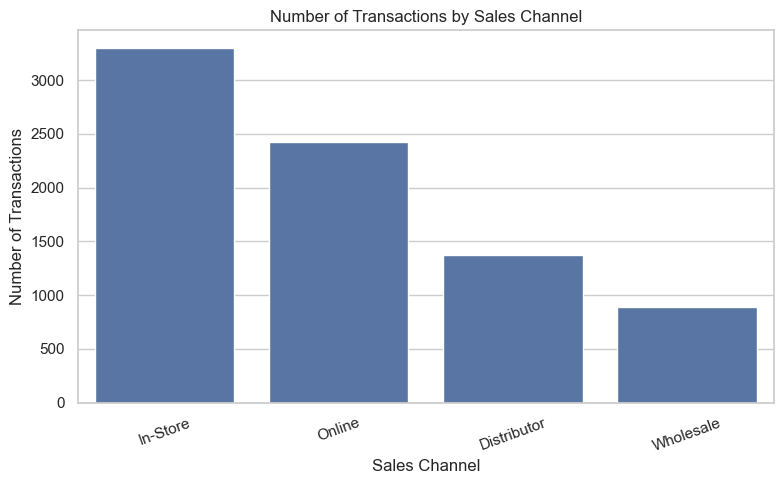

In [37]:
channel_counts = df["Sales Channel"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values
)

plt.title("Number of Transactions by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Observation

The distribution of transactions across sales channels provides an overview of how customers place their orders. This helps understand the overall transaction mix before performing customer-level segmentation.

In [39]:
df["PurchaseValue"] = (
    df["Order Quantity"]
    * df["Unit Price"]
    * (1 - df["Discount Applied"])
)

In [40]:
df[[
    "Order Quantity",
    "Unit Price",
    "Discount Applied",
    "PurchaseValue"
]].head()

,Order Quantity,Unit Price,Discount Applied,PurchaseValue
0,5,1963.1,0.075,9079.3375
1,3,3939.6,0.075,10932.3900
2,1,1775.5,0.050,1686.7250
3,8,2324.9,0.075,17204.2600
4,8,1822.4,0.100,13121.2800


In [41]:
df["Revenue"] = df["PurchaseValue"]

df["Cost"] = (
    df["Order Quantity"]
    * df["Unit Cost"]
)

df["Profit"] = df["Revenue"] - df["Cost"]

In [42]:
df[[
    "Revenue",
    "Cost",
    "Profit"
]].head()

,Revenue,Cost,Profit
0,9079.3375,5005.905,4073.4325
1,10932.3900,10045.980,886.4100
2,1686.7250,781.220,905.5050
3,17204.2600,11717.496,5486.7640
4,13121.2800,11809.152,1312.1280


In [43]:
reference_date = df["OrderDate"].max()

print("Latest order date:", reference_date)

Latest order date: 2020-12-30 00:00:00


In [44]:
rfm = df.groupby("_CustomerID").agg({
    "OrderDate": lambda x: (reference_date - x.max()).days,
    "OrderNumber": "nunique",
    "PurchaseValue": "sum"
})

rfm.rename(columns={
    "OrderDate": "Recency",
    "OrderNumber": "Frequency",
    "PurchaseValue": "Monetary"
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
_CustomerID,,,
1,7,152,1.175021e+06
2,7,135,1.179320e+06
3,8,181,1.628232e+06
4,3,167,1.569468e+06
5,28,159,1.426164e+06


In [45]:
rfm.shape

(50, 3)

In [46]:
avg_purchase = df.groupby("_CustomerID")["PurchaseValue"].mean()

rfm["AveragePurchaseValue"] = avg_purchase

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue
_CustomerID,,,,
1,7,152,1.175021e+06,7730.399391
2,7,135,1.179320e+06,8735.706907
3,8,181,1.628232e+06,8995.759627
4,3,167,1.569468e+06,9398.009760
5,28,159,1.426164e+06,8969.584969


In [47]:
rfm["CustomerLifetimeValue"] = (
    rfm["AveragePurchaseValue"] * rfm["Frequency"]
)

In [48]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
_CustomerID,,,,,
1,7,152,1.175021e+06,7730.399391,1.175021e+06
2,7,135,1.179320e+06,8735.706907,1.179320e+06
3,8,181,1.628232e+06,8995.759627,1.628232e+06
4,3,167,1.569468e+06,9398.009760,1.569468e+06
5,28,159,1.426164e+06,8969.584969,1.426164e+06


### Customer Lifetime Value

The dataset does not contain a direct customer lifespan or retention period. Therefore, a historical revenue-based Customer Lifetime Value proxy is calculated as:

Customer Lifetime Value = Average Purchase Value × Purchase Frequency

This represents the customer's observed value within the available transaction history rather than a future lifetime-value forecast.

In [49]:
rfm.describe()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
count,50.000000,50.00000,5.000000e+01,50.000000,5.000000e+01
mean,5.100000,159.82000,1.462868e+06,9143.248661,1.462868e+06
std,5.395576,14.23088,1.816775e+05,651.053045,1.816775e+05
min,0.000000,135.00000,1.175021e+06,7730.399391,1.175021e+06
25%,2.000000,151.25000,1.346074e+06,8594.248086,1.346074e+06
50%,3.000000,157.50000,1.443861e+06,9234.616737,1.443861e+06
75%,7.000000,167.75000,1.592754e+06,9569.802927,1.592754e+06
max,28.000000,210.00000,2.012877e+06,10857.576554,2.012877e+06


In [50]:
rfm[[
    "AveragePurchaseValue",
    "Frequency",
    "CustomerLifetimeValue"
]].describe()

,AveragePurchaseValue,Frequency,CustomerLifetimeValue
count,50.000000,50.00000,5.000000e+01
mean,9143.248661,159.82000,1.462868e+06
std,651.053045,14.23088,1.816775e+05
min,7730.399391,135.00000,1.175021e+06
25%,8594.248086,151.25000,1.346074e+06
50%,9234.616737,157.50000,1.443861e+06
75%,9569.802927,167.75000,1.592754e+06
max,10857.576554,210.00000,2.012877e+06


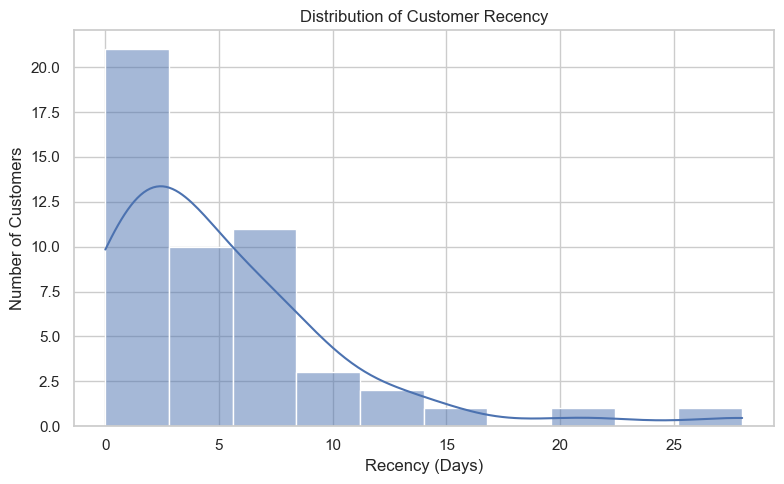

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Recency"],
    bins=10,
    kde=True
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

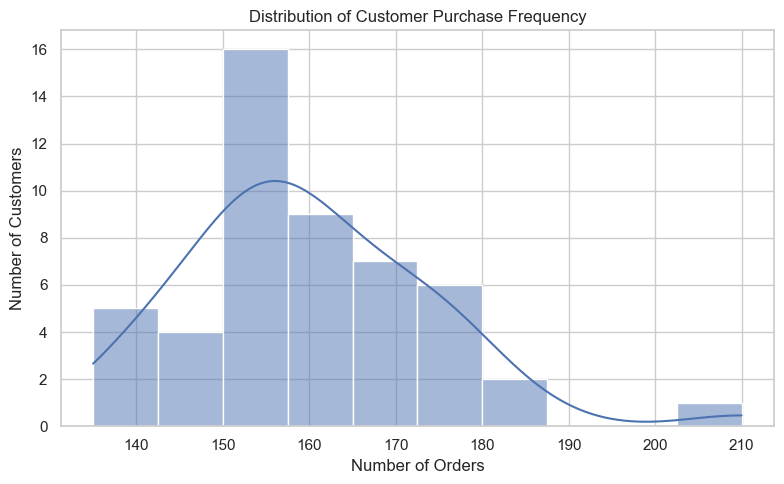

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Frequency"],
    bins=10,
    kde=True
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

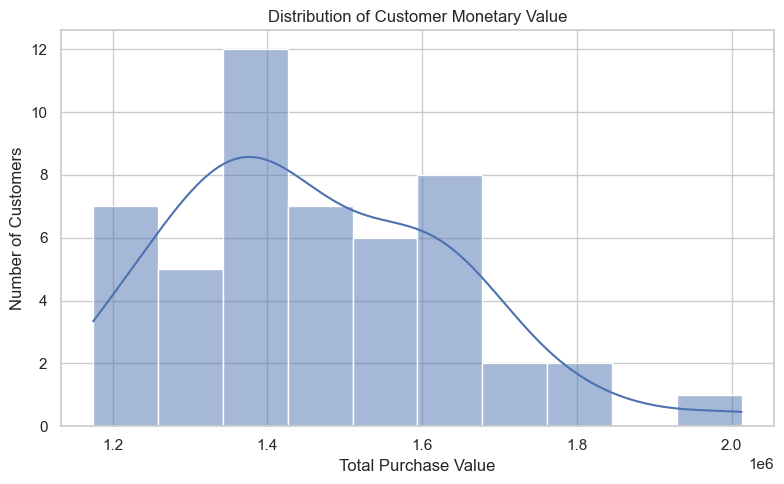

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Monetary"],
    bins=10,
    kde=True
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Purchase Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [54]:
features = [
    "Recency",
    "Frequency",
    "Monetary"
]

X = rfm[features]

X.head()

,Recency,Frequency,Monetary
_CustomerID,,,
1,7,152,1.175021e+06
2,7,135,1.179320e+06
3,8,181,1.628232e+06
4,3,167,1.569468e+06
5,28,159,1.426164e+06


## 4. Feature Selection

RFM analysis is used to represent customer purchasing behaviour:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique orders placed by the customer.
- **Monetary:** Total purchase value generated by the customer.

These three behavioural features are selected for customer segmentation.

In [55]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=rfm.index
)

X_scaled.head()

,Recency,Frequency,Monetary
_CustomerID,,,
1,0.355715,-0.555088,-1.600469
2,0.355715,-1.761801,-1.576562
3,0.542934,1.503423,0.919452
4,-0.393159,0.509659,0.592711
5,4.287307,-0.058206,-0.204077


In [56]:
X_scaled.describe()

,Recency,Frequency,Monetary
count,5.000000e+01,5.000000e+01,5.000000e+01
mean,3.996803e-17,5.018208e-16,4.707346e-16
std,1.010153e+00,1.010153e+00,1.010153e+00
min,-9.548151e-01,-1.761801e+00,-1.600469e+00
25%,-5.803778e-01,-6.083255e-01,-6.493891e-01
50%,-3.931592e-01,-1.646809e-01,-1.056790e-01
75%,3.557154e-01,5.628963e-01,7.221890e-01
max,4.287307e+00,3.561934e+00,3.058131e+00


In [57]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

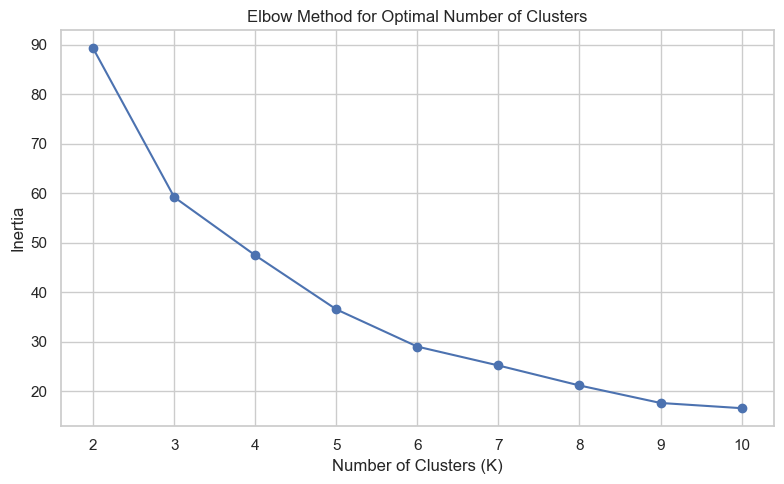

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [59]:
optimal_k = 4

In [60]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

In [61]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster
_CustomerID,,,,,,
1,7,152,1.175021e+06,7730.399391,1.175021e+06,0
2,7,135,1.179320e+06,8735.706907,1.179320e+06,0
3,8,181,1.628232e+06,8995.759627,1.628232e+06,1
4,3,167,1.569468e+06,9398.009760,1.569468e+06,1
5,28,159,1.426164e+06,8969.584969,1.426164e+06,2


In [62]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    25
1    15
2     2
3     8
Name: count, dtype: int64

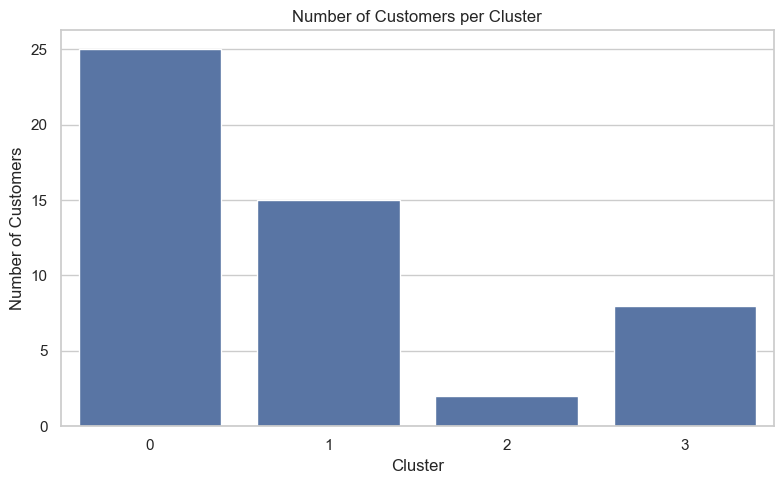

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [64]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary",
    "AveragePurchaseValue",
    "CustomerLifetimeValue"
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
0,3.40,149.88,1332694.21,8901.71,1332694.21
1,2.73,174.27,1669266.29,9592.28,1669266.29
2,24.50,155.00,1338406.82,8626.02,1338406.82
3,10.00,165.00,1513777.06,9185.44,1513777.06


In [65]:
cluster_profile["CustomerCount"] = rfm.groupby("Cluster").size()

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,CustomerCount
Cluster,,,,,,
0,3.40,149.88,1332694.21,8901.71,1332694.21,25
1,2.73,174.27,1669266.29,9592.28,1669266.29,15
2,24.50,155.00,1338406.82,8626.02,1338406.82,2
3,10.00,165.00,1513777.06,9185.44,1513777.06,8


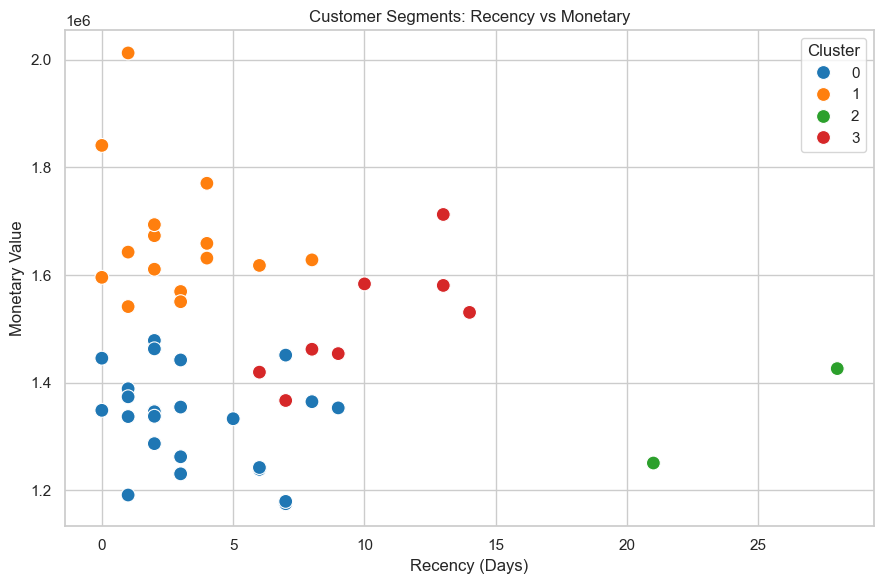

In [66]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

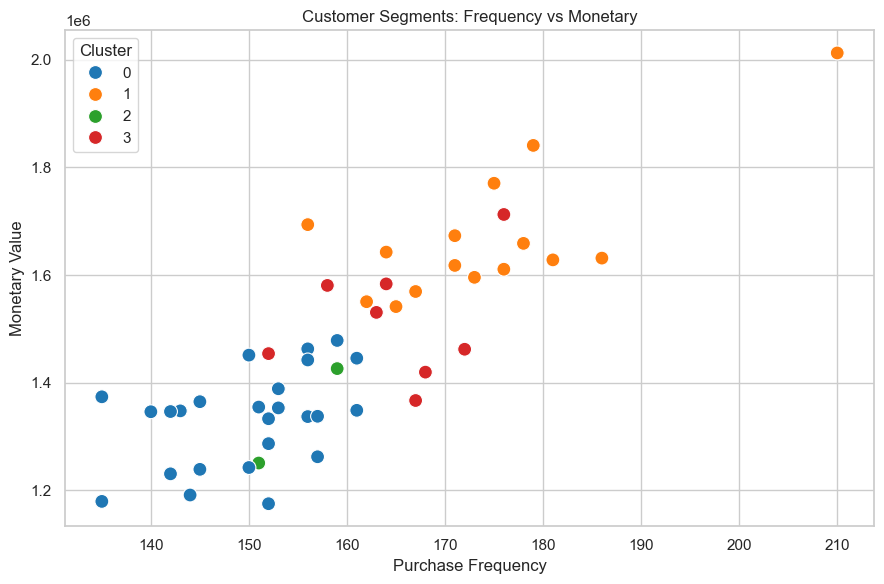

In [67]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

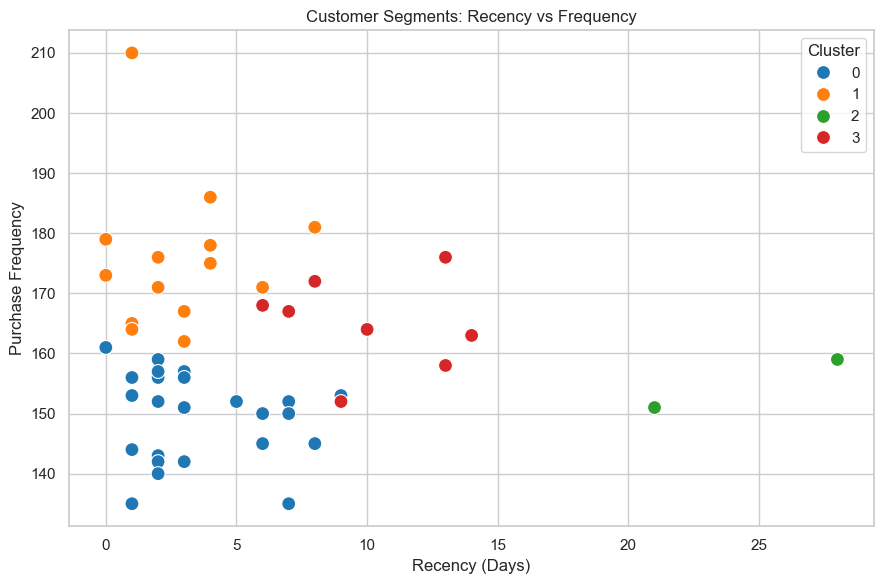

In [68]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

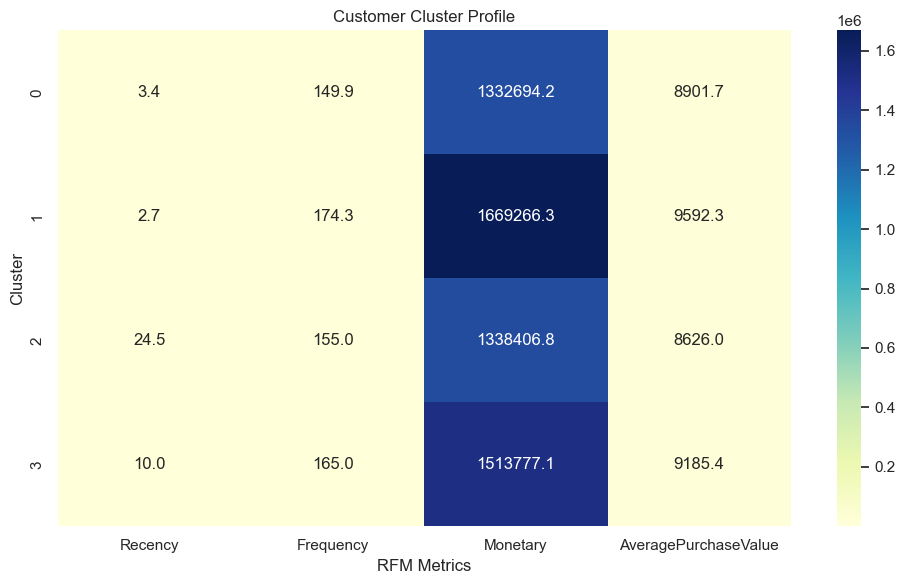

In [69]:
heatmap_data = cluster_profile[[
    "Recency",
    "Frequency",
    "Monetary",
    "AveragePurchaseValue"
]]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Customer Cluster Profile")
plt.xlabel("RFM Metrics")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [70]:
cluster_profile.sort_values(
    by="Monetary",
    ascending=False
)

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,CustomerCount
Cluster,,,,,,
1,2.73,174.27,1669266.29,9592.28,1669266.29,15
3,10.00,165.00,1513777.06,9185.44,1513777.06,8
2,24.50,155.00,1338406.82,8626.02,1338406.82,2
0,3.40,149.88,1332694.21,8901.71,1332694.21,25


In [71]:
cluster_profile.sort_values(
    by="Frequency",
    ascending=False
)

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,CustomerCount
Cluster,,,,,,
1,2.73,174.27,1669266.29,9592.28,1669266.29,15
3,10.00,165.00,1513777.06,9185.44,1513777.06,8
2,24.50,155.00,1338406.82,8626.02,1338406.82,2
0,3.40,149.88,1332694.21,8901.71,1332694.21,25


In [72]:
cluster_profile.sort_values(
    by="Recency",
    ascending=True
)

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,CustomerCount
Cluster,,,,,,
1,2.73,174.27,1669266.29,9592.28,1669266.29,15
0,3.40,149.88,1332694.21,8901.71,1332694.21,25
3,10.00,165.00,1513777.06,9185.44,1513777.06,8
2,24.50,155.00,1338406.82,8626.02,1338406.82,2


## 5. Customer Segment Marketing Recommendations

The clusters are interpreted based on their Recency, Frequency, and Monetary values. Marketing actions are designed according to the behavioural characteristics of each customer segment.

## 6. Conclusion

This customer segmentation analysis used RFM-based behavioural features and K-Means clustering to divide customers into meaningful groups.

The analysis considered:

- Recency of customer purchases
- Purchase frequency
- Monetary purchase value
- Customer lifetime value proxy
- Standardized behavioural features
- Elbow Method for selecting the number of clusters
- K-Means clustering
- Cluster-level profiling
- Customer segment visualization

The resulting customer segments can help businesses develop targeted marketing strategies instead of applying the same strategy to every customer.

Different segments can be approached using retention campaigns, loyalty programs, personalized promotions, cross-selling, and win-back campaigns depending on their purchasing behaviour.